In [2]:
import subprocess, sys 
for pkg in ['pandas', 'numpy', 'matplotlib', 'seaborn', 'plotly', 'openpyxl']:  subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q']) 
print('All libraries are ready!') 

All libraries are ready!


In [3]:
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install seaborn
!pip install plotly
!pip install openpyxl


Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [3]:
import numpy as np  
import matplotlib.pyplot as plt 
import matplotlib.ticker as mticker 

import pandas as pd
import seaborn as sns  
import plotly.express as px 
import plotly.graph_objects as go 
from plotly.subplots import make_subplots 

import warnings 
warnings.filterwarnings('ignore') 
sns.set_style('whitegrid') 
plt.rcParams['figure.figsize'] = (10, 5) 
money_fmt = mticker.FuncFormatter(lambda x, _: f"${x:,.0f}") 
print('Libraries imported successfully!')



Libraries imported successfully!


In [4]:
df = pd.read_excel('finance_transactions_dataset.xlsx')
print(df.shape) # e.g. (1000, 14) 
print(df.columns.tolist())



(1000, 14)
['Transaction_ID', 'Company', 'Sector', 'Department', 'Transaction_Type', 'Category', 'Amount', 'Tax_Rate', 'Tax_Amount', 'Net_Amount', 'Currency', 'Transaction_Date', 'Approval_Status', 'Analyst']


In [11]:
df.head()

,Transaction_ID,Company,Sector,Department,Transaction_Type,Category,Amount,Tax_Rate,Tax_Amount,Net_Amount,Currency,Transaction_Date,Approval_Status,Analyst,Year,Month
0,TXN1001,GreenEnergy,Energy,Marketing,Loan Repayment,N/A,104037.35,0.09,9363.36,94673.99,USD,2022-05-24,Pending,Analyst_B,2022,2022-05
1,TXN1002,LogiTrans,Logistics,IT,Loan Repayment,N/A,431438.64,0.10,43143.86,388294.78,USD,2023-08-04,Pending,Analyst_D,2023,2023-08
2,TXN1003,EduGroup,Education,Sales,Investment,N/A,494837.13,0.18,89070.68,405766.45,GBP,2023-08-05,Rejected,Analyst_B,2023,2023-08
3,TXN1004,HealthPlus,Healthcare,Sales,Revenue,N/A,59347.25,0.09,5341.25,54006.00,USD,2024-11-01,Pending,Analyst_A,2024,2024-11
4,TXN1005,EduGroup,Education,Finance,Loan Repayment,N/A,132500.40,0.15,19875.06,112625.34,GBP,2021-09-16,Approved,Analyst_C,2021,2021-09


In [7]:
df.info

<bound method DataFrame.info of     Transaction_ID      Company      Sector Department Transaction_Type  \
0          TXN1001  GreenEnergy      Energy  Marketing   Loan Repayment   
1          TXN1002    LogiTrans   Logistics         IT   Loan Repayment   
2          TXN1003     EduGroup   Education      Sales       Investment   
3          TXN1004   HealthPlus  Healthcare      Sales          Revenue   
4          TXN1005     EduGroup   Education    Finance   Loan Repayment   
..             ...          ...         ...        ...              ...   
995        TXN1996     MediaMax       Media        NaN          Revenue   
996        TXN1997   HealthPlus  Healthcare  Marketing          Revenue   
997        TXN1998     TechCorp  Technology         IT   Loan Repayment   
998        TXN1999     MediaMax       Media         IT   Loan Repayment   
999        TXN2000    RetailHub      Retail      Sales       Investment   

    Category     Amount  Tax_Rate  Tax_Amount  Net_Amount Currency 

In [8]:
df.describe().round(2)

,Amount,Tax_Rate,Tax_Amount,Net_Amount
count,961.00,1000.00,1000.00,960.00
mean,248309.09,0.18,44196.90,203859.56
std,145329.13,0.07,33447.57,120727.44
min,5132.61,0.05,355.38,3644.15
25%,115322.10,0.12,16896.31,94843.24
50%,250121.30,0.18,35780.50,200693.33
75%,375654.46,0.24,66364.00,308532.69
max,499771.64,0.30,148757.97,454365.87


In [9]:
df.isnull().sum()

Transaction_ID        0
Company              44
Sector                0
Department           54
Transaction_Type      0
Category            789
Amount               39
Tax_Rate              0
Tax_Amount            0
Net_Amount           40
Currency              0
Transaction_Date     48
Approval_Status      39
Analyst              45
dtype: int64

In [10]:
df.dropna(subset=['Amount', 'Net_Amount', 'Transaction_Date',  'Approval_Status'], 
 inplace=True) 
print('Rows remaining:', len(df))


Rows remaining: 845


In [18]:
df[['Company', 'Department', 'Analyst']] =df[['Company', 'Department', 'Analyst']].fillna('Unknown')
df['Category'] = df['Category'].fillna('N/A')

In [19]:
print(df[['Company','Department','Analyst','Category']].isnull().sum())

Company       0
Department    0
Analyst       0
Category      0
dtype: int64


In [7]:
df['Transaction_Date'] = pd.to_datetime(df['Transaction_Date'],  errors='coerce') 
df.dropna(subset=['Transaction_Date'], inplace=True) 
df['Year'] = df['Transaction_Date'].dt.year 
df['Month'] = df['Transaction_Date'].dt.to_period('M').astype(str) 
print('Sample dates:') 
print(df[['Transaction_Date', 'Year', 'Month']].head(3))


Sample dates:
  Transaction_Date  Year    Month
0       2022-05-24  2022  2022-05
1       2023-08-04  2023  2023-08
2       2023-08-05  2023  2023-08


In [10]:
df.drop_duplicates(inplace=True) 
print('Final row count:', len(df))


Final row count: 952


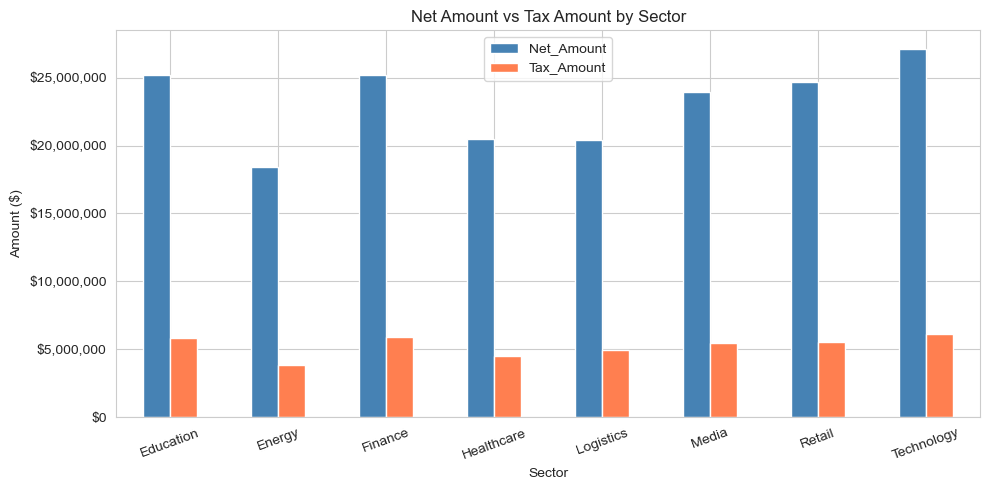

In [24]:
df.groupby('Sector')[['Net_Amount', 'Tax_Amount']].sum().plot(kind='bar',  color=['steelblue', 'coral']) 
plt.title('Net Amount vs Tax Amount by Sector') 
plt.ylabel('Amount ($)') 
plt.xticks(rotation=20) 
plt.gca().yaxis.set_major_formatter(money_fmt) # show real numbers, not  2.5e7 
plt.tight_layout() 
plt.show()


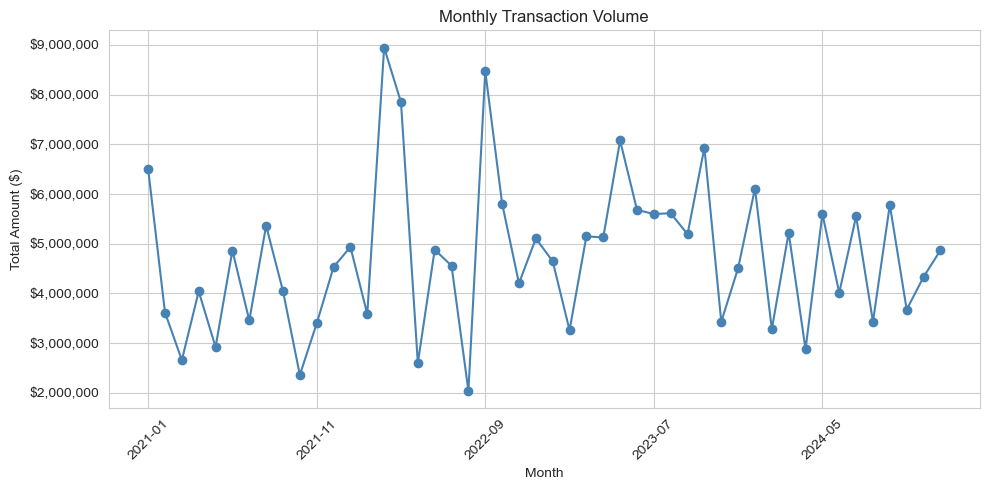

In [25]:
df.groupby('Month')['Amount'].sum().plot(kind='line', marker='o',  color='steelblue') 
plt.title('Monthly Transaction Volume') 
plt.ylabel('Total Amount ($)') 
plt.xticks(rotation=45) 
plt.gca().yaxis.set_major_formatter(money_fmt) # show real numbers, not  2.5e7 
plt.tight_layout() 
plt.show()


In [ ]:
df['Approval_Status'].value_counts().plot(kind='pie', autopct='%1.1f%%',  startangle=140) 
plt.title('Approval Status Distribution') 
plt.ylabel('') # hides the default y-axis label on pie charts plt.tight_layout() 
plt.show()

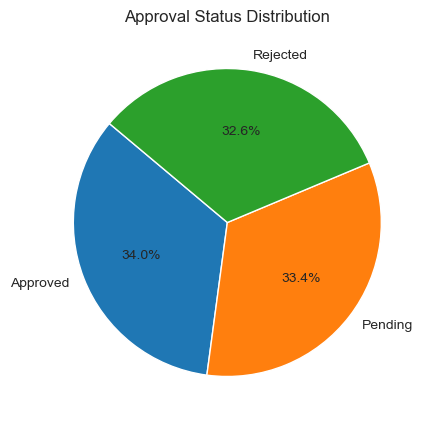

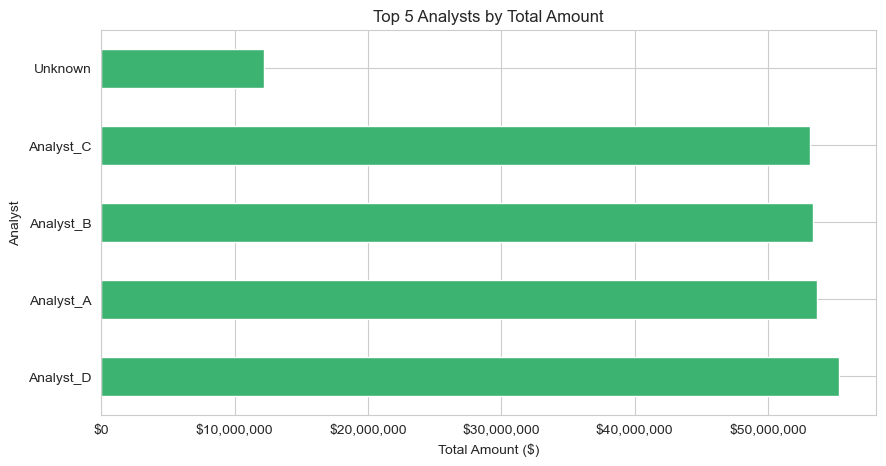

In [27]:
df.groupby('Analyst')['Amount'].sum().nlargest(5).plot(kind='barh',  color='mediumseagreen') 
plt.title('Top 5 Analysts by Total Amount') 
plt.xlabel('Total Amount ($)') 
plt.gca().xaxis.set_major_formatter(money_fmt) # x-axis for horizontal bars plt.tight_layout() 
plt.show()


In [29]:
print('=' * 46)
print(' FINANCE DATASET SUMMARY')
print('=' * 46)

print(f"Transactions: {len(df):,}")
print(f"Total Amount: ${df['Amount'].sum():,.0f}")
print(f"Total Tax Paid: ${df['Tax_Amount'].sum():,.0f}")
print(f"Total Net Amount: ${df['Net_Amount'].sum():,.0f}")
print(f"Avg Tax Rate: {df['Tax_Rate'].mean() * 100:.1f}%")

print(f"Approval Rate: {(df['Approval_Status'] == 'Approved').mean() * 100:.1f}%")

print(f"Top Sector: {df.groupby('Sector')['Amount'].sum().idxmax()}")
print(f"Top Analyst: {df.groupby('Analyst')['Amount'].sum().idxmax()}")


 FINANCE DATASET SUMMARY
Transactions: 952
Total Amount: $227,716,080
Total Tax Paid: $42,164,951
Total Net Amount: $185,453,377
Avg Tax Rate: 17.8%
Approval Rate: 32.7%
Top Sector: Technology
Top Analyst: Analyst_D


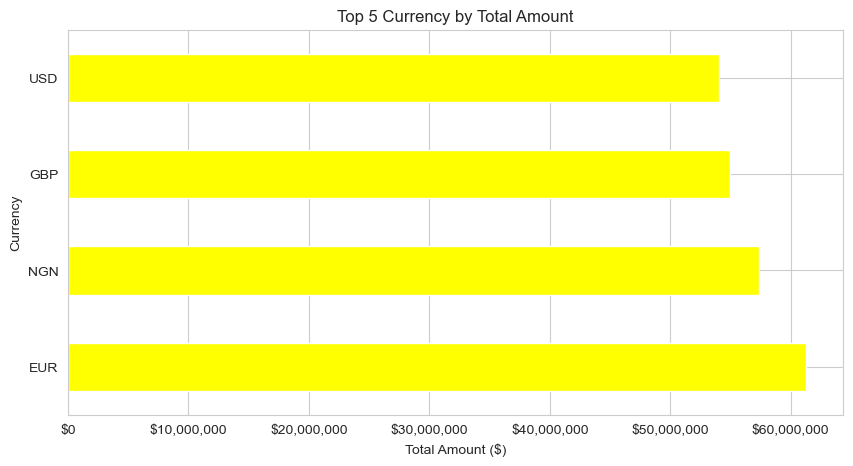

In [30]:
#ASSESSMENT
1
df.groupby('Currency')['Amount'].sum().nlargest(5).plot(kind='barh',  color='yellow') 
plt.title('Top 5 Currency by Total Amount') 
plt.xlabel('Total Amount ($)') 
plt.gca().xaxis.set_major_formatter(money_fmt) # x-axis for horizontal bars plt.tight_layout() 
plt.show()


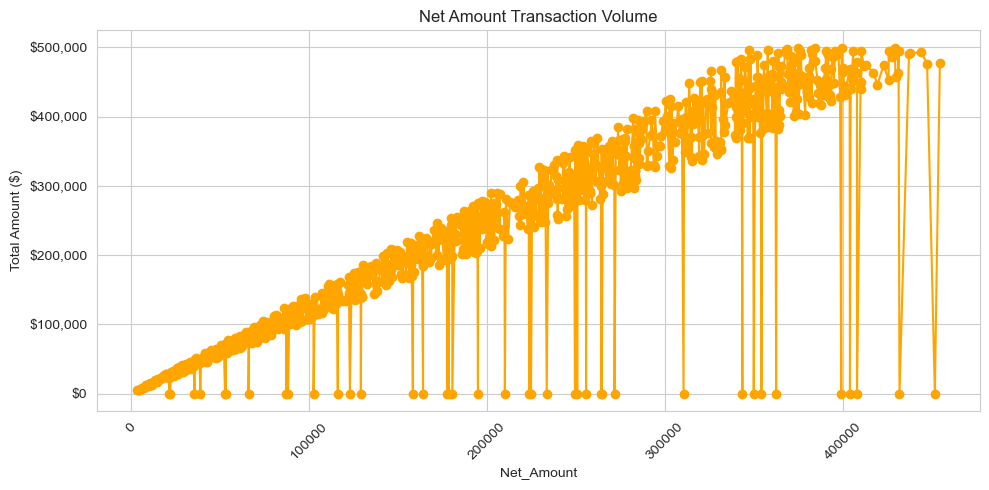

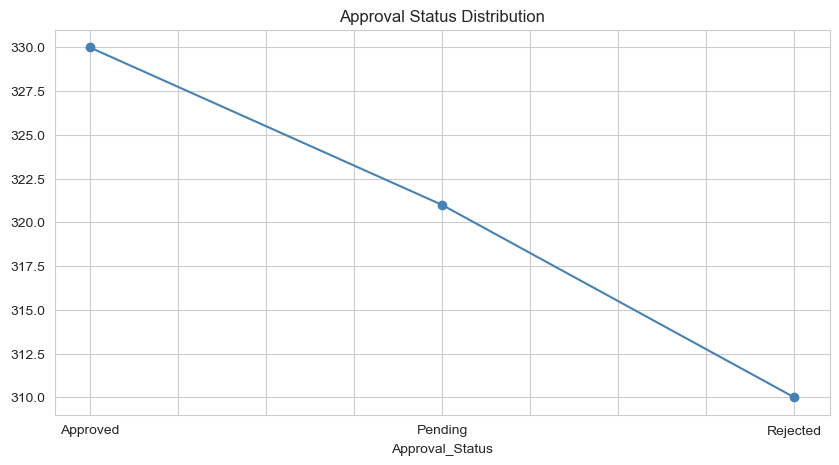

In [5]:
2
df.groupby('Net_Amount')['Amount'].sum().plot(kind='line', marker='o',  color='orange') 
plt.title('Net Amount Transaction Volume') 
plt.ylabel('Total Amount ($)') 
plt.xticks(rotation=45) 
plt.gca().yaxis.set_major_formatter(money_fmt) # show real numbers, not  2.5e7 
plt.tight_layout() 
plt.show()

df['Approval_Status'].value_counts().plot(kind='line',marker='o',  color='steelblue')
plt.title('Approval Status Distribution') 
plt.ylabel('') # hides the default y-axis label on pie charts plt.tight_layout() 
plt.show()

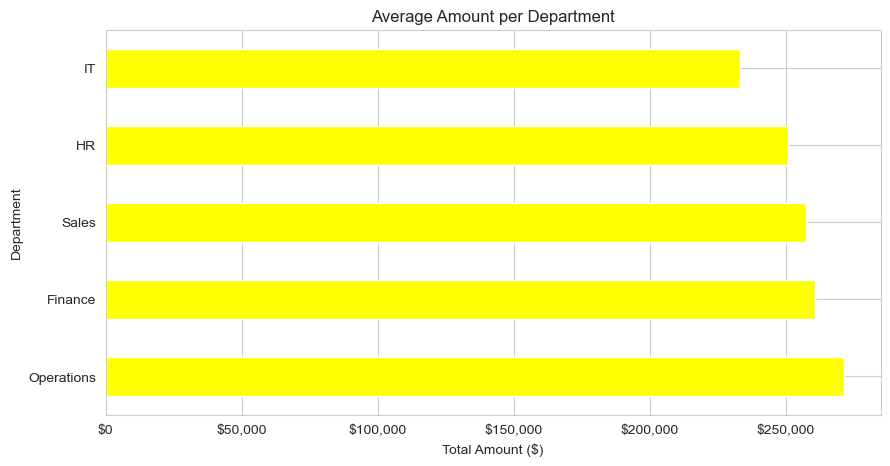

In [8]:
#3
df.groupby('Department')['Amount'].mean().nlargest(5).plot(kind='barh',  color='yellow') 
plt.title('Average Amount per Department') 
plt.xlabel('Total Amount ($)') 
plt.gca().xaxis.set_major_formatter(money_fmt) # x-axis for horizontal bars plt.tight_layout() 
plt.show()

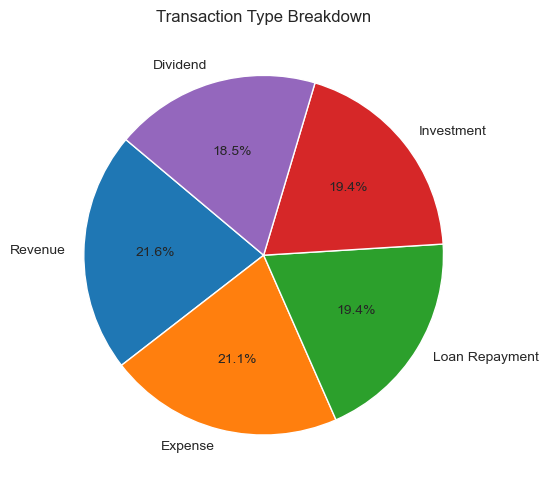

In [12]:
#4
df['Transaction_Type'].value_counts().plot( kind='pie',autopct='%1.1f%%',startangle=140)

plt.title('Transaction Type Breakdown')
plt.ylabel('')  # hides y-axis label
plt.tight_layout()
plt.show()

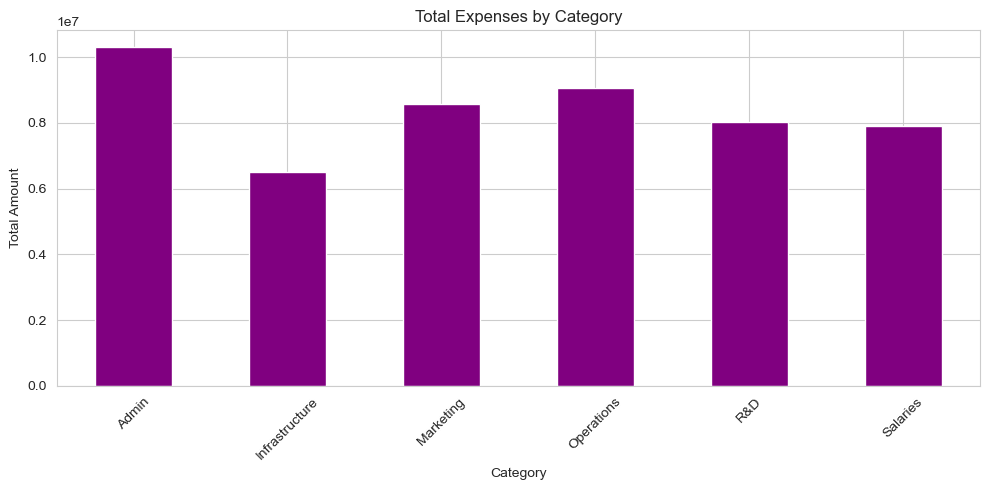

In [17]:
#4

df[df['Transaction_Type'] == 'Expense'].groupby('Category')['Amount'] .sum()  .plot(kind='bar',color='purple')

plt.title('Total Expenses by Category')
plt.xlabel('Category')
plt.ylabel('Total Amount')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()